In [1]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
dataset = load_dataset("emotion")
dataset["train"] = dataset["train"].shuffle(seed=SEED).select(range(2000))
dataset["validation"] = dataset["validation"].shuffle(seed=SEED).select(range(500))
dataset["test"] = dataset["test"].shuffle(seed=SEED).select(range(500))

print(dataset)

print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

labels = dataset["train"].features["label"].names
print("Classes:", labels)

print("Examples:")
for i in range(5):
    print(dataset["train"][i]["text"], "->", labels[dataset["train"][i]["label"]])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 500
    })
})
Train: 2000
Validation: 500
Test: 500
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Examples:
while cycling in the country -> fear
i had pocket qq and was feeling pretty confident lol -> joy
i am in no way complaining or whining or feeling ungrateful -> sadness
i feel a bit stressed because it feels like im supposed to do something all the time and that i should be reading now -> anger
i tell the people closest to me things that i am feeling and its as if they arent surprised because theyd known it all along -> surprise


In [4]:
"""
Классифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).
"""

'\nКлассифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).\n'

Классифицируем эмоции текста (6 классов: joy, sadness, anger, fear, love, surprise).

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

texts = [dataset["train"][i]["text"] for i in range(3)]

encodings = tokenizer(texts, padding=True, truncation=True)

for i, text in enumerate(texts):
    print("TEXT:", text)
    print("TOKENS:", tokenizer.tokenize(text))
    print("INPUT_IDS:", encodings["input_ids"][i])
    print("ATTENTION:", encodings["attention_mask"][i])
    print("WITH SPECIAL TOKENS:", tokenizer.convert_ids_to_tokens(encodings["input_ids"][i]))
    print()

print("PADDING EXAMPLE:")
for i in range(len(texts)):
    print(encodings["input_ids"][i])

TEXT: while cycling in the country
TOKENS: ['while', 'cycling', 'in', 'the', 'country']
INPUT_IDS: [101, 2096, 9670, 1999, 1996, 2406, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
ATTENTION: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
WITH SPECIAL TOKENS: ['[CLS]', 'while', 'cycling', 'in', 'the', 'country', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

TEXT: i had pocket qq and was feeling pretty confident lol
TOKENS: ['i', 'had', 'pocket', 'q', '##q', 'and', 'was', 'feeling', 'pretty', 'confident', 'lo', '##l']
INPUT_IDS: [101, 1045, 2018, 4979, 1053, 4160, 1998, 2001, 3110, 3492, 9657, 8840, 2140, 102, 0, 0, 0]
ATTENTION: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
WITH SPECIAL TOKENS: ['[CLS]', 'i', 'had', 'pocket', 'q', '##q', 'and', 'was', 'feeling', 'pretty', 'confident', 'lo', '##l', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

TEXT: i am in no way complaining or whining or feeling ungrateful
TOKENS: ['i', 'am', 'in', 'no', 'w

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
).to(device)

inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=1)

for text, pred in zip(texts, preds):
    print(text, "->", labels[pred])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


while cycling in the country -> anger
i had pocket qq and was feeling pretty confident lol -> anger
i am in no way complaining or whining or feeling ungrateful -> anger


In [7]:
"""
Модель не обучена на эмоциях - предсказания неверные, случайные.
"""

'\nМодель не обучена на эмоциях - предсказания неверные, случайные.\n'

Модель не обучена на эмоциях - предсказания неверные, случайные.

In [8]:
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 13448.97 examples/s]


In [9]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=1)
    
    acc = accuracy_score(labels_true, preds)
    f1 = f1_score(labels_true, preds, average="macro")
    
    return {"accuracy": acc, "f1_macro": f1}

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    
    evaluation_strategy="epoch",
    save_strategy="epoch",
    
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    
    seed=SEED,
    logging_steps=100,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\transformers\training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [11]:
trainer.train()

D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': 1.4536, 'grad_norm': 8.166947364807129, 'learning_rate': 1.7333333333333336e-05, 'epoch': 0.4}
{'loss': 1.0597, 'grad_norm': 12.724328994750977, 'learning_rate': 1.4666666666666666e-05, 'epoch': 0.8}
{'eval_loss': 0.8072866201400757, 'eval_accuracy': 0.732, 'eval_f1_macro': 0.5498538389474277, 'eval_runtime': 26.0744, 'eval_samples_per_second': 19.176, 'eval_steps_per_second': 2.416, 'epoch': 1.0}


D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.839, 'grad_norm': 7.683882236480713, 'learning_rate': 1.2e-05, 'epoch': 1.2}
{'loss': 0.5518, 'grad_norm': 9.13646411895752, 'learning_rate': 9.333333333333334e-06, 'epoch': 1.6}
{'loss': 0.4593, 'grad_norm': 1.3487510681152344, 'learning_rate': 6.666666666666667e-06, 'epoch': 2.0}
{'eval_loss': 0.5181767344474792, 'eval_accuracy': 0.83, 'eval_f1_macro': 0.7643113294813264, 'eval_runtime': 25.7912, 'eval_samples_per_second': 19.386, 'eval_steps_per_second': 2.443, 'epoch': 2.0}


D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': 0.3124, 'grad_norm': 14.055296897888184, 'learning_rate': 4.000000000000001e-06, 'epoch': 2.4}
{'loss': 0.2609, 'grad_norm': 20.33332633972168, 'learning_rate': 1.3333333333333334e-06, 'epoch': 2.8}


D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4953802824020386, 'eval_accuracy': 0.848, 'eval_f1_macro': 0.7971145782170591, 'eval_runtime': 26.3663, 'eval_samples_per_second': 18.964, 'eval_steps_per_second': 2.389, 'epoch': 3.0}
{'train_runtime': 1618.126, 'train_samples_per_second': 3.708, 'train_steps_per_second': 0.463, 'train_loss': 0.6745822296142578, 'epoch': 3.0}


TrainOutput(global_step=750, training_loss=0.6745822296142578, metrics={'train_runtime': 1618.126, 'train_samples_per_second': 3.708, 'train_steps_per_second': 0.463, 'train_loss': 0.6745822296142578, 'epoch': 3.0})

In [13]:
metrics = trainer.state.log_history

for log in metrics:
    if "eval_f1_macro" in log:
        print(log)
print("Best model checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)

{'eval_loss': 0.8072866201400757, 'eval_accuracy': 0.732, 'eval_f1_macro': 0.5498538389474277, 'eval_runtime': 26.0744, 'eval_samples_per_second': 19.176, 'eval_steps_per_second': 2.416, 'epoch': 1.0, 'step': 250}
{'eval_loss': 0.5181767344474792, 'eval_accuracy': 0.83, 'eval_f1_macro': 0.7643113294813264, 'eval_runtime': 25.7912, 'eval_samples_per_second': 19.386, 'eval_steps_per_second': 2.443, 'epoch': 2.0, 'step': 500}
{'eval_loss': 0.4953802824020386, 'eval_accuracy': 0.848, 'eval_f1_macro': 0.7971145782170591, 'eval_runtime': 26.3663, 'eval_samples_per_second': 18.964, 'eval_steps_per_second': 2.389, 'epoch': 3.0, 'step': 750}
Best model checkpoint: ./results\checkpoint-750
Best metric: 0.7971145782170591


In [14]:
test_results = trainer.evaluate(tokenized_datasets["test"])
print(test_results)

D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4254457354545593, 'eval_accuracy': 0.852, 'eval_f1_macro': 0.7386631489934881, 'eval_runtime': 26.0153, 'eval_samples_per_second': 19.219, 'eval_steps_per_second': 2.422, 'epoch': 3.0}
{'eval_loss': 0.4254457354545593, 'eval_accuracy': 0.852, 'eval_f1_macro': 0.7386631489934881, 'eval_runtime': 26.0153, 'eval_samples_per_second': 19.219, 'eval_steps_per_second': 2.422, 'epoch': 3.0}


In [15]:
preds_output = trainer.predict(tokenized_datasets["test"])

logits = preds_output.predictions
y_pred = np.argmax(logits, axis=1)
y_true = preds_output.label_ids

D:\Project_university\Artificial-Intelligence-Engineering\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [16]:
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", acc)
print("F1_macro:", f1)

Accuracy: 0.852
F1_macro: 0.7386631489934881


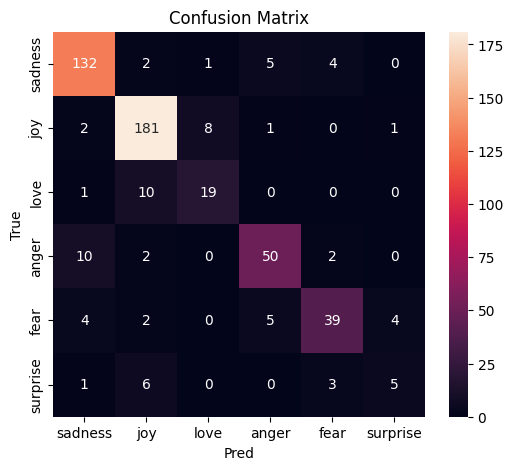

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Pred")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [18]:
df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": [labels[i] for i in y_true],
    "pred_label": [labels[i] for i in y_pred],
    "confidence": np.max(torch.softmax(torch.tensor(logits), dim=1).numpy(), axis=1)
})

df_sample = df.sample(10, random_state=SEED)
print(df_sample)

df_sample.to_csv("./artifacts/sample_predictions.csv", index=False)

                                                  text true_label pred_label  \
361  i told my fiance how i am feeling so angry and...      anger      anger   
73   i feel i m handling it well and i m enjoying i...        joy        joy   
374  i feel these days living in fears just another...        joy        joy   
155  im just now realizing i didnt have a diet coke...        joy        joy   
104              im feeling rather angsty and listless    sadness      anger   
394                   i got off the phone feeling numb    sadness    sadness   
377    i feel last time ure the one that feel paranoid       fear       fear   
124  i feel slytherin is my house slytherin is for ...        joy        joy   
68   i feel completely rude with not keeping up wit...      anger      anger   
450  i feel like most teams would have appeased jac...      anger      anger   

     confidence  
361    0.962393  
73     0.968245  
374    0.944135  
155    0.967155  
104    0.844960  
394    0.98

Модель ошиблась, потому что в тексте есть слово “angsty”, которое по форме и смыслу близко к anger, и модель воспринимает его как сигнал злости